# 📊 EDIS 8100 · Week 2 · Exploring Learning Data

### Mapping the Learning Analytics Landscape and Theoretical Lenses

**Estimated time:** about 35 minutes of core work, in class.

*Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia*

---

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Aggregate** a real institutional clickstream to the student level with `groupby`, and **join** it to an assessment table with `merge`, saying out loud after every step who disappeared and what that costs.
2. **Read** a scatterplot of activity against achievement and say what it does and does not license you to claim.
3. **Use the claim ladder** (feature, indicator, construct) to name the distance between a column in a CSV and a thing that theory says matters.
4. **Defend a data preparation decision**, including the choice of axis scale, as an argument rather than a formatting preference.

---

## Something changed since Week 1

Week 1 ran on invented students. From today the data is real: enrollment records and daily click counts from a course that actually ran, at a university that actually exists, involving people who actually studied.

Real data does not arrange itself into a lesson. In the next twenty minutes you will meet a sixth of the cohort with no click recorded anywhere, activity recorded before the course started, a column with blanks in it, a category label typed two different ways, and two separate runs of the same course sitting in one file waiting for a careless join to fuse them into one. None of that is a flaw in the download. That is what an institutional export looks like when it arrives, and meeting it well is most of the job.

---

## How this notebook works

New to code? Good. You are exactly who this was designed for.

- **Run the cells from top to bottom.** Click a cell and press **Shift + Enter**. Then do the next one.
- **Nothing here can break your computer.** This runs on a Google server, on a published, openly licensed dataset. The worst case is an error message, which is just the computer telling you where it got confused.
- **If something looks wrong, start over from the top.** In Colab: **Runtime > Restart and run all**. That fixes the large majority of problems, and it is what experienced people do too.
- **You never need to write code from scratch today.** The core path runs untouched. The cells marked ✏️ **Your turn** already contain working values, so the notebook runs whether or not you change them. Change them anyway when you get there.
- **Reading is the work.** The code is short. The interpretation prompts after each chart are the actual assignment.

**Section markers:** ⚙️ setup · 📊 analysis · ✏️ your turn · 💬 discuss · ✅ wrap up

## 📄 Where this data came from

You should never analyze data whose origin you cannot state. Here is this week's origin, and it is worth two minutes before you load anything.

**Dataset.** The Open University Learning Analytics Dataset (OULAD), restricted to module **BBB** and its two presentations, **2013J** and **2014J**. A *presentation* is one running of a module, the way EDIS 8100 Fall 2026 is one running of EDIS 8100.

**Who collected it, in one sentence.** The Open University is a UK distance-teaching university where almost all instruction happens inside an online Virtual Learning Environment, so its own systems recorded every enrollment, every resource click, and every assignment score as a by-product of teaching; its analytics team then anonymized seven modules' worth of those records and published them so that researchers with no access to a live student system could work on real learning data.

**License.** CC BY 4.0. You may use, share, and adapt it, including commercially, provided you give credit.

**Citation, APA 7:**

> Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171.

**What it cost to get here.** Publishing student records is not a matter of uploading a folder. Names are gone; students are integers. Calendar dates are gone; every date in this dataset is a **day number counted from the first day of the module**, which is why you are about to see negative dates. Home addresses are gone; in their place sits `imd_band`, the decile of the UK Index of Multiple Deprivation for the small area a student lives in, an area-level measure of socioeconomic deprivation that describes a neighborhood and not a person. The module itself is identified only as BBB.

Every one of those substitutions protects somebody and costs you something as an analyst. That trade is not a footnote to learning analytics. It is the field's standing condition.

**The stance we take.** In Week 1 the data were invented precisely so that nobody could be harmed by our practice. This data is real. The people in it studied a real module, some of them passed, more of them withdrew than you will expect, and none of them are in the room to correct you. The ask is the same one as Week 1, only sharper: **say who could be harmed by a claim before you make it.**

**Your one sentence, for when someone asks.** *"Anonymized records from one module of the UK Open University, 2013 and 2014, collected by the university's own teaching systems and published by Kuzilek, Hlosta, and Zdrahal under CC BY 4.0."*

## ⚙️ Setup: run the next cell first

The cell below downloads this week's six files from the course dataset repository. No accounts, no passwords, no installs. It takes a couple of seconds and prints what arrived.

If you are running this on a machine with no internet connection, the cell will tell you so in plain English instead of showing you a wall of red.

In [1]:
# ⚙️ SETUP CELL. Downloads this week's data and sets the plotting defaults.
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Default matplotlib look plus a faint grid, so every chart looks the same for everyone.
plt.style.use('default')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.dpi'] = 100

BASE = 'https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main/oulad-bbb'

FILES = {
    'student_info':         ('studentInfo.csv',         'one enrollment: who signed up, and how it ended'),
    'student_vle':          ('studentVle.csv.gz',       'one student, one resource, one day: the clickstream'),
    'student_assessment':   ('studentAssessment.csv',   'one submitted assessment: the score'),
    'assessments':          ('assessments.csv',         'one assessment: its type, due day, and weight'),
    'student_registration': ('studentRegistration.csv', 'one enrollment: when they registered, when they left'),
    'vle':                  ('vle.csv',                 'one resource in the course website'),
}

tables = {}
try:
    for key, (filename, _) in FILES.items():
        tables[key] = pd.read_csv(f'{BASE}/{filename}')
except Exception as err:
    print('=' * 74)
    print('The data did not download, so nothing below this cell will work yet.')
    print()
    print('This notebook reads six files from the course dataset repository:')
    print('    HakeoungLee/edis8100-datasets, folder oulad-bbb')
    print(f'    {BASE}')
    print()
    print('The usual cause is no internet connection in this runtime. Check your')
    print('connection, then use Runtime > Restart and run all. If the repository')
    print('itself is unreachable, tell Dr. Lee: the link above is the one to send.')
    print()
    print(f'Technical detail, for the record: {type(err).__name__}: {err}')
    print('=' * 74)
    raise SystemExit('Download failed. The message above says what to do.') from None

student_info         = tables['student_info']
student_vle          = tables['student_vle']
student_assessment   = tables['student_assessment']
assessments          = tables['assessments']
student_registration = tables['student_registration']
vle                  = tables['vle']

print('Six files arrived from HakeoungLee/edis8100-datasets (folder oulad-bbb).')
print()
total_rows = 0
for key, (filename, grain) in FILES.items():
    df = tables[key]
    total_rows += len(df)
    print(f'  {filename:<26} {len(df):>7,} rows x {df.shape[1]:>2} cols   one row is {grain}')
print()
print(f'  {"TOTAL":<26} {total_rows:>7,} rows')
print()
print('Module:', student_info['code_module'].unique().tolist(),
      '   Presentations:', sorted(student_info['code_presentation'].unique().tolist()))
print('Real, published, CC BY 4.0 data. Kuzilek, Hlosta, and Zdrahal (2017).')

Six files arrived from HakeoungLee/edis8100-datasets (folder oulad-bbb).

  studentInfo.csv              4,529 rows x 12 cols   one row is one enrollment: who signed up, and how it ended
  studentVle.csv.gz          891,062 rows x  6 cols   one row is one student, one resource, one day: the clickstream
  studentAssessment.csv       21,783 rows x  5 cols   one row is one submitted assessment: the score
  assessments.csv                 18 rows x  6 cols   one row is one assessment: its type, due day, and weight
  studentRegistration.csv      4,529 rows x  5 cols   one row is one enrollment: when they registered, when they left
  vle.csv                        528 rows x  6 cols   one row is one resource in the course website

  TOTAL                      922,449 rows

Module: ['BBB']    Presentations: ['2013J', '2014J']
Real, published, CC BY 4.0 data. Kuzilek, Hlosta, and Zdrahal (2017).


## 📊 1. Meet the tables

Three of those six files carry the weight today, and they have three genuinely different origins. The difference is the whole lesson of the first ten minutes.

- `studentVle` is a **log**. One row says: on day *d*, student *s* clicked resource *r* this many times. Nobody designed it to answer a research question. It is exhaust from a website doing its job.
- `studentAssessment` is a **measurement**. One row per submitted assessment, produced by an instrument somebody built on purpose and marked by somebody trying to measure something.
- `studentInfo` is an **administrative record**. One row per enrollment, assembled by a registry for reasons that have nothing to do with research: funding, reporting, compliance.

Learning analytics almost always means putting those kinds of data next to each other and arguing about what the pairing means. Notice the **grain** of each file, meaning what one row is, before you go further. Getting the grain wrong is the most common way an analysis goes quietly wrong.

In [2]:
print('studentInfo: one row per ENROLLMENT (a student in a presentation)')
display(student_info.head(3))

print('studentVle: one row per STUDENT x RESOURCE x DAY')
display(student_vle.head(3))

print('studentAssessment: one row per SUBMITTED ASSESSMENT')
display(student_assessment.head(3))

print('Rows are not students. Count carefully:')
print('  studentInfo rows (enrollments) :', f'{len(student_info):,}')
print('  distinct id_student values     :', f"{student_info['id_student'].nunique():,}")
print('  studentVle rows                :', f'{len(student_vle):,}')
print('  total clicks in studentVle     :', f"{student_vle['sum_click'].sum():,}")

studentInfo: one row per ENROLLMENT (a student in a presentation)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,BBB,2013J,23632,F,East Anglian Region,A Level or Equivalent,40-50%,0-35,0,60,N,Withdrawn
1,BBB,2013J,23798,M,Wales,A Level or Equivalent,50-60%,0-35,0,60,N,Distinction
2,BBB,2013J,25629,F,Scotland,Lower Than A Level,20-30%,0-35,0,120,N,Withdrawn


studentVle: one row per STUDENT x RESOURCE x DAY


,code_module,code_presentation,id_student,id_site,date,sum_click
0,BBB,2013J,560773,704206,-23,1
1,BBB,2013J,560773,704205,-23,1
2,BBB,2013J,560773,704204,-23,1


studentAssessment: one row per SUBMITTED ASSESSMENT


,id_assessment,id_student,date_submitted,is_banked,score
0,14996,23798,18,0,90.0
1,14996,27759,18,0,61.0
2,14996,30091,24,0,80.0


Rows are not students. Count carefully:
  studentInfo rows (enrollments) : 4,529
  distinct id_student values     : 4,482
  studentVle rows                : 891,062
  total clicks in studentVle     : 3,052,400


### 💬 Before you go further

- What did a student have to **do** for a `studentVle` row to appear? What could a student do in this course that would leave **no row at all**?
- `studentInfo` has more rows than it has distinct students. Before you scroll down, write your best guess for why.
- Baker and Inventado (2014) describe educational data mining and learning analytics as two traditions that grew up around exactly this kind of trace. Which questions does a click log make easy to ask, and which questions does it quietly make impossible?

## 📊 2. What an export actually looks like when it arrives

Here is the part Week 1 could not teach you, because Week 1's data was built to be teachable.

Four things are wrong with this download, in the sense that four things will produce a wrong answer if you do not look. We are going to meet all four, decide what to do about each one **in front of you**, and say what the decision costs. That last step is the one people skip.

### 📊 2a. Mess one: two courses wearing the same name

`code_presentation` takes two values. 2013J and 2014J are two different runs of module BBB, a year apart, with different students, different teaching staff, and, as you will see shortly, different assessment structures.

Some students appear in **both**. They took the module, it did not go well, and they took it again. If you group by `id_student` alone, those two attempts get added together into one imaginary person who clicked more than anyone actually did.

In [3]:
print('Enrollments per presentation:')
print(student_info['code_presentation'].value_counts().sort_index().to_string())
print()

n_rows     = len(student_info)
n_students = student_info['id_student'].nunique()
n_repeat   = n_rows - n_students
print(f'{n_rows:,} enrollment rows but only {n_students:,} distinct students.')
print(f'{n_repeat} students sat this module twice, once in each presentation.')
print()

example_id = 151917
print(f'Student {example_id}, both attempts:')
display(student_info[student_info['id_student'] == example_id]
        [['id_student', 'code_presentation', 'num_of_prev_attempts',
          'studied_credits', 'final_result']])

clicks_both = (student_vle[student_vle['id_student'] == example_id]
               .groupby('code_presentation')['sum_click'].sum())
print('Their clicks, kept separate:')
print(clicks_both.to_string())
print(f'Their clicks, carelessly added together: {clicks_both.sum():,}')
print()
print(f'A groupby on id_student alone reports one student with {clicks_both.sum():,} '
      'clicks who both failed and passed.')

Enrollments per presentation:
code_presentation
2013J    2237
2014J    2292

4,529 enrollment rows but only 4,482 distinct students.
47 students sat this module twice, once in each presentation.

Student 151917, both attempts:


,id_student,code_presentation,num_of_prev_attempts,studied_credits,final_result
71,151917,2013J,3,60,Fail
2296,151917,2014J,4,60,Pass


Their clicks, kept separate:
code_presentation
2013J    909
2014J    713
Their clicks, carelessly added together: 1,622

A groupby on id_student alone reports one student with 1,622 clicks who both failed and passed.


**The decision, out loud.** For the rest of this notebook the unit of analysis is the **enrollment**, not the student, and the join key is the pair `(id_student, code_presentation)`. The person above appears twice, because they had two different experiences of this course and it would be a lie to average them.

**What it costs.** Our rows are no longer independent people. Forty-seven of them are somebody's second try, and a second try is not a fresh start. Any model we build later has that dependency inside it, and we would have to say so in a paper.

### 📊 2b. Mess two: activity before the course starts

`date` in `studentVle` is a day number counted from the first day of the module, because calendar dates were removed to protect the students. Day 0 is day one of the course.

Negative numbers are therefore not corrupt. They are people looking at the course website before the course opens.

In [4]:
d = student_vle['date']
print(f'date runs from {d.min()} to {d.max()}    (day 0 = first day of the module)')

pre = student_vle[student_vle['date'] < 0]
print(f'Rows recorded BEFORE day 0 : {len(pre):,} of {len(student_vle):,} '
      f'({100 * len(pre) / len(student_vle):.1f}%)')
print(f'Distinct students doing it : {pre["id_student"].nunique():,}')
print()

reg = student_registration['date_registration']
print(f'Registration day: earliest {reg.min():.0f}, median {reg.median():.0f}, latest {reg.max():.0f}')
print(f'Enrollments registered before day 0 : {(reg < 0).sum():,} of {len(student_registration):,}')
print(f'Enrollments with a blank registration day: {reg.isna().sum()}')

date runs from -23 to 268    (day 0 = first day of the module)
Rows recorded BEFORE day 0 : 46,884 of 891,062 (5.3%)
Distinct students doing it : 2,739

Registration day: earliest -198, median -57, latest 44
Enrollments registered before day 0 : 4,452 of 4,529
Enrollments with a blank registration day: 3


**The decision, out loud.** We keep the pre-start clicks. Looking at the site before it opens is engagement, arguably the most voluntary engagement in the whole file, and dropping it would silently punish the students who did it.

**What it costs.** Our activity totals now cover an unequal window: someone who registered nearly two hundred days early had more opportunity to accumulate pre-start clicks than someone who registered after the module had already begun. "Total clicks" is not a rate, and comparing two students on it compares two different amounts of opportunity. ✏️ Your turn 1 lets you switch this decision off and watch what moves.

### 📊 2c. Mess three: a blank column, and one label typed out of pattern

`imd_band` is the deprivation decile of the neighborhood a student lives in. It should have ten categories, each one written the same way. Count them, and look at how they are spelled.

In [5]:
print('imd_band, exactly as it arrived:')
print(student_info['imd_band'].value_counts(dropna=False).to_string())
print()
print(f"Distinct labels, blanks not counted : {student_info['imd_band'].nunique()}")
print(f"Rows where imd_band is blank        : {student_info['imd_band'].isna().sum()}")
print()
print('Ten deciles, ten labels. Nine of them carry a percent sign. One does not.')
print('Sorted the way pandas sorts text:')
print(sorted(student_info['imd_band'].dropna().unique().tolist()))
print()

# What happens to somebody who writes out the ten labels the sensible way?
expected = [f'{i}-{i + 10}%' for i in range(0, 100, 10)]
print('The ten labels a careful analyst would write by hand:')
print(expected)

unmatched = ~student_info['imd_band'].isin(expected)
odd_label = int((student_info['imd_band'] == '10-20').sum())
blank     = int(student_info['imd_band'].isna().sum())
print()
print(f'Rows that list does NOT match : {int(unmatched.sum()):,} of {len(student_info):,} '
      f'({100 * unmatched.mean():.1f}%)')
print(f'  because the band is blank   : {blank}')
print(f'  because it says "10-20"     : {odd_label}   <- one missing percent sign')
print()
print(f'Map deciles to numbers with that list and {odd_label} real students silently')
print('become missing, all from the same band. Nothing errors. Nothing warns you.')

imd_band, exactly as it arrived:
imd_band
0-10%      591
20-30%     566
10-20      557
30-40%     495
40-50%     474
50-60%     449
60-70%     412
70-80%     353
80-90%     335
90-100%    268
NaN         29

Distinct labels, blanks not counted : 10
Rows where imd_band is blank        : 29

Ten deciles, ten labels. Nine of them carry a percent sign. One does not.
Sorted the way pandas sorts text:
['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

The ten labels a careful analyst would write by hand:
['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

Rows that list does NOT match : 586 of 4,529 (12.9%)
  because the band is blank   : 29
  because it says "10-20"     : 557   <- one missing percent sign

Map deciles to numbers with that list and 557 real students silently
become missing, all from the same band. Nothing errors. Nothing warns you.


**The decision, out loud.** We are not using `imd_band` in today's analysis, so we will not repair it here. We are showing it to you because this is the shape of the thing: a socioeconomic variable, the exact variable an equity audit would lean on, arriving with a blank for 29 people and one band typed out of pattern.

**What it costs, if you ever do use it.** The mess is quiet, which is what makes it dangerous. There is no duplicate category to spot and no error to catch. But the moment you convert those labels to numbers with a hand-written list, or filter with a `str.endswith('%')`, the 557 students in the second-most-deprived band drop out of your analysis without a word, and they are not a random 557. Drop the 29 blanks on top of that and you have also deleted people whose deprivation was never recorded, and "not recorded" is rarely random either. Week 3 audits a model by subgroup, and this is the column it will want.

### 📊 2d. Mess four: enrollments with no activity at all

The clickstream can only contain students who clicked. To find the students who did not, you have to start from the roster and look for who is **missing** from the log. This is the single most important habit in this notebook.

In [6]:
KEY = ['id_student', 'code_presentation']

any_activity = student_vle[KEY].drop_duplicates()
roster = student_info.merge(any_activity.assign(clicked=True), on=KEY, how='left')
roster['clicked'] = roster['clicked'].fillna(False)

n_silent = int((~roster['clicked']).sum())
print(f'Enrollments in studentInfo        : {len(roster):,}')
print(f'Enrollments with at least 1 click : {int(roster["clicked"].sum()):,}')
print(f'Enrollments with NO clicks ever   : {n_silent:,}  '
      f'({100 * n_silent / len(roster):.1f}%, about 1 in {len(roster) / n_silent:.1f})')
print()

print('How every enrollment ended:')
print(student_info['final_result'].value_counts().to_string())
print()
print('Percent of the whole cohort:')
print((100 * student_info['final_result'].value_counts(normalize=True)).round(1).to_string())

Enrollments in studentInfo        : 4,529
Enrollments with at least 1 click : 3,791
Enrollments with NO clicks ever   : 738  (16.3%, about 1 in 6.1)

How every enrollment ended:
final_result
Pass           1868
Withdrawn      1393
Fail            912
Distinction     356

Percent of the whole cohort:
final_result
Pass           41.2
Withdrawn      30.8
Fail           20.1
Distinction     7.9


Read those two blocks together before you move on.

About one enrollment in six never registers a single click, and close to a third of the cohort ends in `Withdrawn`. This is a distance-learning module with open entry, so that is not a scandal, it is the population. But it means the students who most concern an early-warning system are exactly the students who leave the least data behind. Hold on to that. It comes back in ten minutes with a number attached.

### 📊 2e. The scoping decision

We are going to analyze **one presentation, 2013J**, and say so every time we report a number.

Why not both? Because they are not the same course. Look at the table the next cell prints: 2013J was assessed with six tutor-marked assignments and five computer-marked ones, while 2014J was assessed with five tutor-marked assignments and no computer-marked ones at all, and the first of those five carried a weight of zero. Both years end with an exam. Pooling the two would average two different grading regimes and call the result a finding.

**What it costs.** We just cut our data in half, and we give up any chance of asking whether a pattern replicates across years. That is a real loss. ✏️ Your turn 2 hands 2014J back to you so you can find out how much the answer depends on which year you happened to pick.

In [7]:
PRESENTATION = '2013J'

print('Assessment structure, side by side:')
display(assessments.pivot_table(index='assessment_type', columns='code_presentation',
                                values='id_assessment', aggfunc='count')
                   .fillna(0).astype(int))

print('Every assessment, its due day (day number), and its weight:')
display(assessments.sort_values(['code_presentation', 'date'])
        [['code_presentation', 'assessment_type', 'date', 'weight']]
        .reset_index(drop=True))

enroll  = student_info[student_info['code_presentation'] == PRESENTATION].copy()
vle_log = student_vle[student_vle['code_presentation'] == PRESENTATION].copy()

print()
print(f'Scoped to {PRESENTATION}:')
print(f'  enrollments      : {len(enroll):,}')
print(f'  clickstream rows : {len(vle_log):,}')
print(f'  total clicks     : {vle_log["sum_click"].sum():,}')
print(f'  day range        : {vle_log["date"].min()} to {vle_log["date"].max()}')

Assessment structure, side by side:


code_presentation,2013J,2014J
assessment_type,,
CMA,5,0
Exam,1,1
TMA,6,5


Every assessment, its due day (day number), and its weight:


,code_presentation,assessment_type,date,weight
0,2013J,TMA,19.0,5.0
1,2013J,TMA,47.0,18.0
2,2013J,CMA,54.0,1.0
3,2013J,CMA,96.0,1.0
4,2013J,TMA,96.0,18.0
5,2013J,CMA,131.0,1.0
6,2013J,TMA,131.0,18.0
7,2013J,CMA,166.0,1.0
8,2013J,TMA,166.0,18.0
9,2013J,CMA,208.0,1.0



Scoped to 2013J:
  enrollments      : 2,237
  clickstream rows : 452,638
  total clicks     : 1,378,656
  day range        : -23 to 268


## 📊 3. From hundreds of thousands of rows to one row per student: `groupby`

The clickstream is at the wrong grain for almost any question we care about. We think in students; the file thinks in student-resource-days. `groupby` is the tool that moves between grains.

`vle_log.groupby('id_student')` says: *split the table into one pile per student.* Then we tell it what to compute on each pile. Two things at once here:

- `sum_click` **summed**, which is total clicks: how much.
- `date` counted for **distinct** values, which is active days: how spread out.

Those are two different ideas about activity and they will not agree.

In [8]:
activity = (
    vle_log.groupby('id_student')
           .agg(total_clicks=('sum_click', 'sum'),
                active_days=('date', 'nunique'))
           .reset_index()
)

print(f'activity now has one row per student who clicked: {activity.shape[0]:,} rows')
display(activity.head())

print('Total clicks per student:')
print(activity['total_clicks'].describe().round(1).to_string())
print()
print(f"median  {activity['total_clicks'].median():,.0f} clicks")
print(f"maximum {activity['total_clicks'].max():,.0f} clicks")
print(f"The busiest student generated "
      f"{activity['total_clicks'].max() / activity['total_clicks'].median():.0f} times the median.")
print()
print(f'Enrollments in the roster          : {len(enroll):,}')
print(f'Students in the activity table     : {len(activity):,}')
print(f'Enrollments the groupby cannot see : {len(enroll) - len(activity):,}')
print('A groupby can only tell you about people who left rows. It has no way to')
print('mention the ones who did not, so you have to remember them yourself.')

activity now has one row per student who clicked: 1,870 rows


,id_student,total_clicks,active_days
0,23798,590,77
1,27759,366,46
2,30091,1332,64
3,31014,531,47
4,31849,1179,80


Total clicks per student:
count     1870.0
mean       737.2
std       1289.5
min          1.0
25%        148.2
50%        386.0
75%        817.2
max      16440.0

median  386 clicks
maximum 16,440 clicks
The busiest student generated 43 times the median.

Enrollments in the roster          : 2,237
Students in the activity table     : 1,870
Enrollments the groupby cannot see : 367
A groupby can only tell you about people who left rows. It has no way to
mention the ones who did not, so you have to remember them yourself.


Look at those numbers before you look at any picture. The median student generated a few hundred clicks; the busiest generated over sixteen thousand. That gap is not a data error. It is the normal shape of behavioral trace data: **heavy tailed**, meaning a small number of people account for an enormous share of the total.

Two histograms, side by side. The left one plots clicks as they are. The right one plots the same students on a **log scale**, where each step along the axis is a multiplication rather than an addition, so 10, 100, and 1,000 sit at even intervals. Same people. Same clicks. Different axis.

Remember what the right panel looks like. In about ten minutes that choice of axis is going to change a headline number by a factor of nearly two, and you will have to decide whether that is allowed.

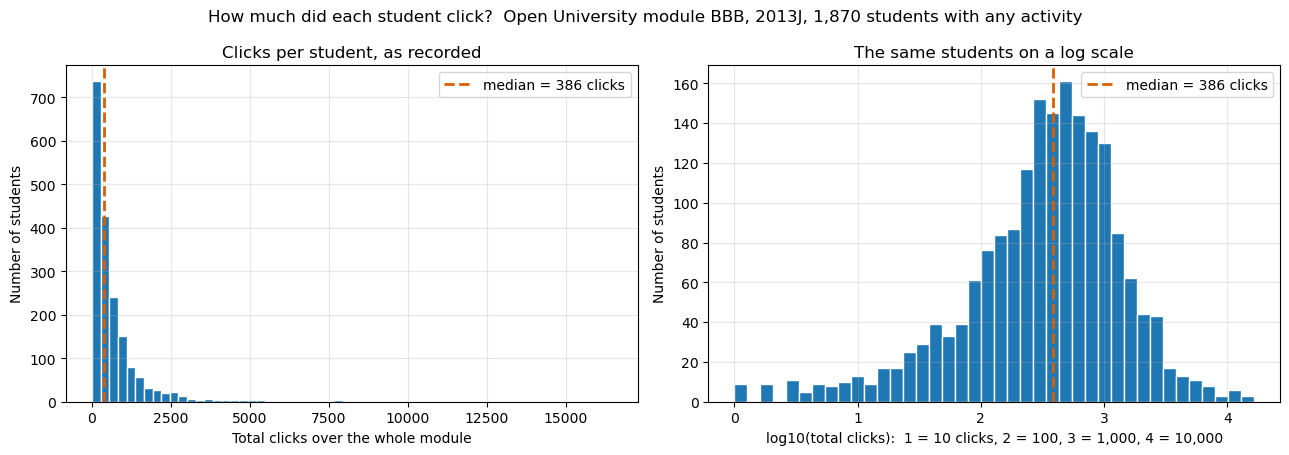

Not on either chart: 367 enrollments with no recorded clicks.
You cannot take the log of zero, so the log panel has no place to put a count of zero.
Neither panel can say whether those enrollments studied off the platform, never
opened it, or opened it in a way this log does not record.


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

med = activity['total_clicks'].median()

ax1.hist(activity['total_clicks'], bins=60, color='#1f77b4', edgecolor='white')
ax1.axvline(med, color='#d95f02', linestyle='--', linewidth=2,
            label=f'median = {med:,.0f} clicks')
ax1.set_title('Clicks per student, as recorded')
ax1.set_xlabel('Total clicks over the whole module')
ax1.set_ylabel('Number of students')
ax1.legend()

ax2.hist(np.log10(activity['total_clicks']), bins=40, color='#1f77b4', edgecolor='white')
ax2.axvline(np.log10(med), color='#d95f02', linestyle='--', linewidth=2,
            label=f'median = {med:,.0f} clicks')
ax2.set_title('The same students on a log scale')
ax2.set_xlabel('log10(total clicks):  1 = 10 clicks, 2 = 100, 3 = 1,000, 4 = 10,000')
ax2.set_ylabel('Number of students')
ax2.legend()

fig.suptitle(f'How much did each student click?  Open University module BBB, {PRESENTATION}, '
             f'{len(activity):,} students with any activity', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Not on either chart: {len(enroll) - len(activity):,} enrollments with no recorded clicks.')
print('You cannot take the log of zero, so the log panel has no place to put a count of zero.')
print('Neither panel can say whether those enrollments studied off the platform, never')
print('opened it, or opened it in a way this log does not record.')

### 💬 Interpret this chart

1. The tail on the right of the first panel is real behavior, not noise. Name **two different students** who could have produced a count out there, one whose count you would read as good news and one whose count you would read as a warning sign.
2. The two panels contain identical information. Which one would you put in front of a program director, and what would each one make them believe?
3. The line printed underneath is the important one. Some enrolled students appear on neither chart. What is the honest way to report a median click count when a sixth of the cohort has been left out of it?

### 📊 3b. The enrollments with no recorded activity

They are not a rounding error and they are not spread evenly across the cohort. We cannot say what these people did, because this file records clicks on one website and nothing else. What we can do is line them up against the one column that says how each enrollment ended.

Read the next chart as a fact about the **record**, not about the people in it. "No recorded clicks" is a statement about what the virtual learning environment logged, and these were adults studying at a distance, most of them in paid employment, many with people at home depending on them.

,enrollments,clicked,never_clicked,pct_never_clicked
final_result,,,,
Distinction,176,176,0,0.0
Pass,896,896,0,0.0
Fail,521,472,49,9.4
Withdrawn,644,326,318,49.4


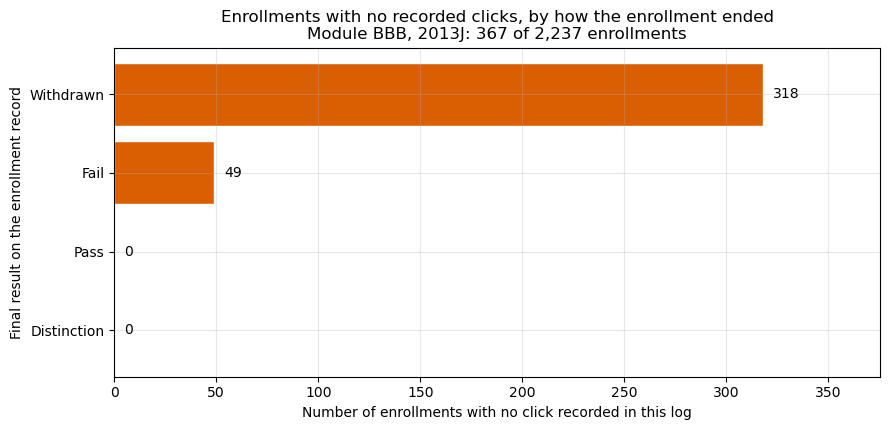

Of the 644 withdrawn enrollments, 318 (49.4%) have no click recorded.
Of the 896 passes and 176 distinctions, 0 did.


In [10]:
enroll_flagged = enroll.merge(activity[['id_student']].assign(clicked=True),
                              on='id_student', how='left')
enroll_flagged['clicked'] = enroll_flagged['clicked'].fillna(False)

silent = enroll_flagged[~enroll_flagged['clicked']]
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']

summary = (enroll_flagged.groupby('final_result')['clicked']
           .agg(enrollments='size', clicked='sum')
           .reindex(order))
summary['never_clicked'] = summary['enrollments'] - summary['clicked']
summary['pct_never_clicked'] = (100 * summary['never_clicked'] / summary['enrollments']).round(1)
display(summary)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(order, summary['never_clicked'].values, color='#d95f02', edgecolor='white')
for i, v in enumerate(summary['never_clicked'].values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=10)
ax.set_title('Enrollments with no recorded clicks, by how the enrollment ended\n'
             f'Module BBB, {PRESENTATION}: {len(silent):,} of {len(enroll):,} enrollments')
ax.set_xlabel('Number of enrollments with no click recorded in this log')
ax.set_ylabel('Final result on the enrollment record')
ax.set_xlim(0, max(summary['never_clicked'].max() * 1.18, 10))
plt.tight_layout()
plt.show()

print(f'Of the {int(summary.loc["Withdrawn", "enrollments"]):,} withdrawn enrollments, '
      f'{int(summary.loc["Withdrawn", "never_clicked"]):,} '
      f'({summary.loc["Withdrawn", "pct_never_clicked"]:.1f}%) have no click recorded.')
print(f'Of the {int(summary.loc["Pass", "enrollments"]):,} passes and '
      f'{int(summary.loc["Distinction", "enrollments"]):,} distinctions, '
      f'{int(summary.loc["Pass", "never_clicked"] + summary.loc["Distinction", "never_clicked"])} did.')

### 💬 Interpret this chart

1. Nearly half of the withdrawn enrollments have no click recorded. Before reaching for an explanation about the people, work down this list in order and write one candidate at each level. **The instrument:** what would somebody have to do for a row to appear here, and what kinds of studying leave no row at all? **The setting:** what does an open-entry distance university's registration calendar and fee-refund window make likely in the first weeks of a module? **The circumstances:** these are adults, most in paid work, who registered a median of 57 days before a course that starts in October. Only after those three, write a candidate about the student. Then count how many of your four are about somebody other than the student.
2. An early-warning system reads the clickstream. What does it actually know about these enrollments on day 14, and what does it only appear to know?
3. Here is the trap the rest of this notebook is built around. To correlate activity with achievement you need students who have both. Every student on this chart has neither. **Before you scroll,** predict which final results are about to disappear from our analysis, and say whether the finding that survives is a finding about the course or a finding about the people who stayed.

## 💬 4. The claim ladder: feature, indicator, construct

Stop here. This is the idea the rest of the semester leans on, and we are naming it in Week 2 so we can point back at it in Week 3, Week 6, and Week 7.

`total_clicks` is a number. The moment you say a sentence about it, you have climbed a ladder, and most arguments in learning analytics are really arguments about which rung somebody is standing on.

| Rung | What it is | Today's example | How much argument it needs |
|---|---|---|---|
| **Feature** | Something the system recorded that you can count without anyone objecting. | `total_clicks = 909` for student 151917 in 2013J. | Almost none. It is arithmetic. |
| **Indicator** | A feature you have **argued** stands in for something educational. | "Total clicks is an indicator of how engaged a student is with the module." | A lot. This is where the work is. |
| **Construct** | The thing you actually care about. Theory defines it. No column contains it. | Engagement. Self-regulated learning. Understanding. | It has a literature, and the literature disagrees. |

Nathan and Sawyer (2014) are useful here precisely because they refuse to let learning be defined by whatever is easy to capture. Their learning sciences constructs (deep conceptual understanding, knowledge built in context, learning made visible through activity) do not sit in a CSV column, and no amount of clicks adds up to one.

Baker and Inventado (2014) describe two research traditions that handle this differently: educational data mining tends to work bottom up from the features toward automated discovery, while learning analytics tends to keep a human holding the construct and asking whether the indicator deserves the name it was given. Neither is the villain. But you have to know which move you are making.

Real data adds a rung below the ladder that synthetic data hid from you. Before a number is even a feature, somebody had to decide it existed: that a page load counts as a click, that a click before day 0 counts at all, that a student who never appears in the log is a person rather than an absence. **The feature is not the bottom of the ladder. The recording decision is.**

**House rule for the rest of the course:** when you make a claim, say which rung it is standing on. "Student 151917 generated 909 clicks in 2013J" is a feature claim and it is free. "Student 151917 was disengaged" is a construct claim and you owe evidence.

### ✏️ Write one line now

In the cell below (it is a text cell, just type), finish these three sentences:

- The feature I have is ...
- I am proposing to treat it as an indicator of ...
- The construct I actually care about is ..., and one thing this feature will definitely miss about it is ...

*(Your answer here. Double click this cell to type in it.)*

- The feature I have is
- I am proposing to treat it as an indicator of
- The construct I actually care about is

## 📊 5. The other table, then the join

To put activity next to achievement we need achievement at the same grain: one number per student.

`studentAssessment` has no `code_presentation` column. It only knows `id_assessment`. So the first move is to look each assessment up in the `assessments` table, which is where the presentation, the type, the due day, and the weight live. This is what a **lookup join** is for, and skipping it is exactly how the two presentations get fused.

Three judgment calls are hiding in the next few lines, and all three are choices you should be able to defend:

1. We keep the assessments with a **recorded score** and drop the handful with a blank score, rather than treating a blank as a zero. A blank could be an ungraded submission or an administrative gap; a zero is a claim that the student failed.
2. We take the **unweighted mean** of a student's scores. The real module weighted them: one tutor-marked assignment counted 5 percent, five counted 18 percent each, and the five computer-marked ones counted 1 percent apiece. An unweighted mean is simpler, and wrong in a specific, statable way.
3. The **final exam is not in this file at all**. Watch for it below. The single highest-stakes measurement in the module, weighted 100, has no submission rows anywhere. Every claim we make today is about coursework, not about final attainment, and if you forget that you will overclaim.

In [11]:
# Step 1: attach the presentation, type, due day, and weight to every submission.
submissions = student_assessment.merge(
    assessments[['id_assessment', 'code_presentation', 'assessment_type', 'date', 'weight']],
    on='id_assessment', how='left'
)
print(f'Submissions after the lookup join: {len(submissions):,}')
print('Submissions that failed to match an assessment: '
      f"{submissions['code_presentation'].isna().sum()}")
print()

subs = submissions[submissions['code_presentation'] == PRESENTATION].copy()
print(f'{PRESENTATION} submissions: {len(subs):,}')
print('By assessment type:')
print(subs['assessment_type'].value_counts().to_string())
print()
print('Assessment types defined for this presentation:',
      assessments[assessments['code_presentation'] == PRESENTATION]['assessment_type'].tolist())
print('Notice which one has no submissions anywhere in the file.')
print()

n_blank = int(subs['score'].isna().sum())
print(f'Submissions with a blank score: {n_blank}   (dropped, not zeroed)')
subs = subs.dropna(subset=['score'])

achievement = (
    subs.groupby('id_student')
        .agg(mean_score=('score', 'mean'),
             n_submissions=('score', 'size'))
        .reset_index()
)
print(f'Students with at least one scored submission: {len(achievement):,}')
display(achievement.head())
print('Scores across this presentation: mean %.1f, sd %.1f'
      % (subs['score'].mean(), subs['score'].std()))

Submissions after the lookup join: 21,783
Submissions that failed to match an assessment: 0

2013J submissions: 14,375
By assessment type:
assessment_type
TMA    7959
CMA    6416

Assessment types defined for this presentation: ['CMA', 'CMA', 'CMA', 'CMA', 'CMA', 'TMA', 'TMA', 'TMA', 'TMA', 'TMA', 'TMA', 'Exam']
Notice which one has no submissions anywhere in the file.

Submissions with a blank score: 10   (dropped, not zeroed)
Students with at least one scored submission: 1,710


,id_student,mean_score,n_submissions
0,23798,93.909091,11
1,27759,76.090909,11
2,30091,88.000000,10
3,31014,90.000000,5
4,31849,78.000000,11


Scores across this presentation: mean 78.9, sd 17.2


### 📊 5b. `merge`, and an honest count of who left

`merge` lines up two tables by the columns they share. `how='inner'` keeps only the students present in **both**, which is the right join for a scatterplot and the wrong join for a conscience: an inner join is where students quietly disappear from an analysis.

So we count before, count after, and then ask the question almost nobody asks: **who left, and were they a random sample?**

activity rows    (clicked at least once)   : 1,870
achievement rows (submitted at least once) : 1,710
panel rows       (did both)                : 1,697

  clicked but never submitted a score : 173
  submitted but no click recorded     : 13
  in the roster, in neither table     : 354

Started from 2,237 enrollments. Analyzing 1,697. Set aside 540 (24.1%).



,in the roster,in our panel,set aside,roster %,panel %
final_result,,,,,
Distinction,176,176,0,7.9,10.4
Pass,896,896,0,40.1,52.8
Fail,521,422,99,23.3,24.9
Withdrawn,644,203,441,28.8,12.0


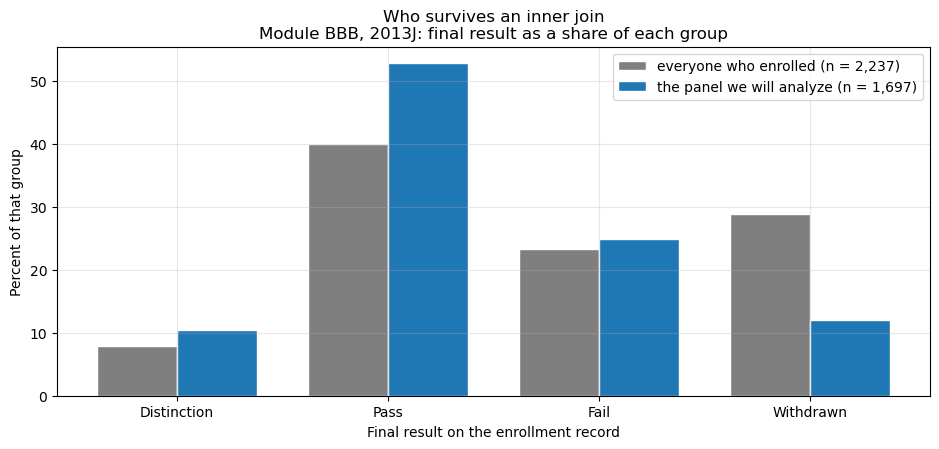

Withdrawn is 28.8% of the cohort and 12.0% of our panel.
Of the 540 enrollments we set aside: 441 withdrew, 99 failed, 0 passed.


In [12]:
panel = activity.merge(achievement, on='id_student', how='inner')
panel = panel.merge(enroll[['id_student', 'final_result']], on='id_student', how='left')

only_clicked   = len(activity) - len(panel)
only_submitted = len(achievement) - len(panel)
neither        = len(enroll) - len(panel) - only_clicked - only_submitted

print(f'activity rows    (clicked at least once)   : {len(activity):,}')
print(f'achievement rows (submitted at least once) : {len(achievement):,}')
print(f'panel rows       (did both)                : {len(panel):,}')
print()
print(f'  clicked but never submitted a score : {only_clicked:,}')
print(f'  submitted but no click recorded     : {only_submitted:,}')
print(f'  in the roster, in neither table     : {neither:,}')
print()
dropped = len(enroll) - len(panel)
print(f'Started from {len(enroll):,} enrollments. Analyzing {len(panel):,}. '
      f'Set aside {dropped:,} ({100 * dropped / len(enroll):.1f}%).')
print()

order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
roster_share = (100 * enroll['final_result'].value_counts(normalize=True)).reindex(order)
panel_share  = (100 * panel['final_result'].value_counts(normalize=True)).reindex(order)
gone = enroll[~enroll['id_student'].isin(panel['id_student'])]
gone_counts = gone['final_result'].value_counts().reindex(order).fillna(0).astype(int)

comparison = pd.DataFrame({
    'in the roster': enroll['final_result'].value_counts().reindex(order),
    'in our panel': panel['final_result'].value_counts().reindex(order),
    'set aside': gone_counts,
    'roster %': roster_share.round(1),
    'panel %': panel_share.round(1),
})
display(comparison)

x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.bar(x - 0.19, roster_share.values, width=0.38, color='#7f7f7f',
       edgecolor='white', label=f'everyone who enrolled (n = {len(enroll):,})')
ax.bar(x + 0.19, panel_share.values, width=0.38, color='#1f77b4',
       edgecolor='white', label=f'the panel we will analyze (n = {len(panel):,})')
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_title('Who survives an inner join\n'
             f'Module BBB, {PRESENTATION}: final result as a share of each group')
ax.set_xlabel('Final result on the enrollment record')
ax.set_ylabel('Percent of that group')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Withdrawn is {roster_share['Withdrawn']:.1f}% of the cohort "
      f"and {panel_share['Withdrawn']:.1f}% of our panel.")
print(f"Of the {dropped:,} enrollments we set aside: "
      f"{gone_counts['Withdrawn']:,} withdrew, {gone_counts['Fail']:,} failed, "
      f"{gone_counts['Pass'] + gone_counts['Distinction']} passed.")

### 💬 Interpret this chart, carefully

This is the most important chart in the notebook, and it is not about learning at all.

1. Every single enrollment we set aside ended in `Fail` or `Withdrawn`. Not one passing student was lost. Say in one sentence what our panel is now a sample **of**.
2. We did not do anything wrong. An inner join is the correct operation for a scatterplot of two variables. So where exactly did the distortion enter, and what is the smallest honest sentence that has to appear next to every number we report from here on?
3. A vendor validates an engagement metric on a panel built exactly this way and reports that it predicts success. What have they actually shown?
4. Now go back and check your prediction from Section 3b. Were you right about which results would vanish?

## 📊 6. Does activity buy achievement?

This is the plot that launched a thousand dashboards. It is usually described as effort on the x axis and outcome on the y axis, and half the trouble in this field lives in that first word: the x axis is a count of clicks on a website, and calling it effort is a claim nobody has argued for yet. Before you run it, **write down your prediction**. Most people expect a clear upward cloud.

We add the least squares line and print two correlations, because one is not enough here.

- **Pearson `r`** runs from -1 to 1 and measures how well a **straight line** fits. On a variable as heavy tailed as click counts, a small Pearson `r` can mean "barely related" or it can mean "related, but not in a straight line," and the number will not tell you which.
- **Spearman's rho** is the same calculation done on **ranks** instead of raw values. It asks a weaker and often more honest question: as one goes up, does the other tend to go up? Because it uses only the ordering, it does not care whether you plot clicks raw, logged, or square rooted.
- `r` squared is the share of the variation in scores that moves **linearly** with recorded activity, in this panel. It describes a fit. It is not a cause, and it is not a property of a student.

Reporting both is not hedging. It is the difference between a claim about people and a claim about the shape you assumed.

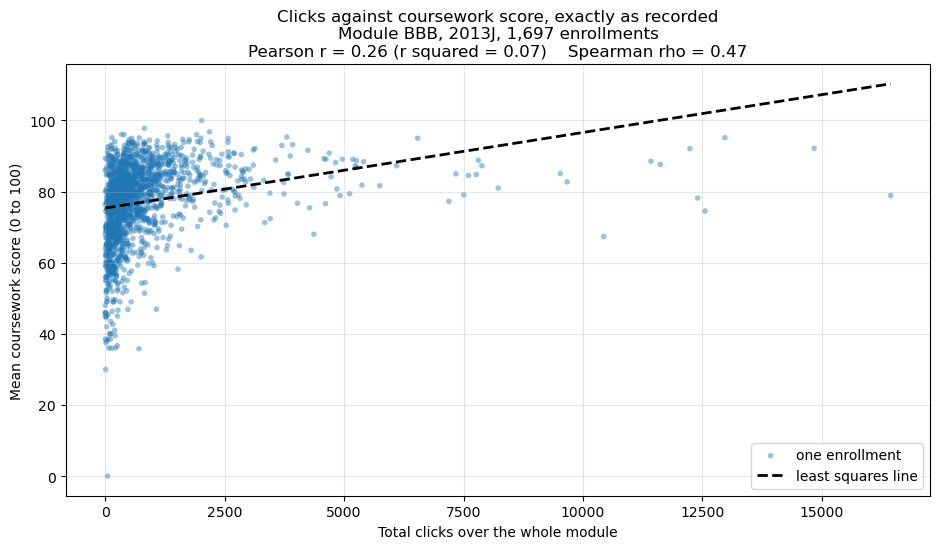

Pearson r (straight line, raw counts) = 0.258
r squared                             = 0.067
   A straight line in raw clicks tracks about 7% of the variation in
   coursework scores, leaving about 93% doing something else.
Spearman rho (ranks)                  = 0.466

Those two numbers disagree, and the disagreement is the finding. Pearson is small
because a straight line fits these points badly. Spearman is larger because the
ordering does hold: enrollments with more recorded clicks do tend to score higher.
Neither number says why, and neither is a fact about any person in this file.


In [13]:
r_raw = panel['total_clicks'].corr(panel['mean_score'])
rho = panel['total_clicks'].corr(panel['mean_score'], method='spearman')

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.scatter(panel['total_clicks'], panel['mean_score'],
           s=16, color='#1f77b4', alpha=0.45, edgecolor='none', label='one enrollment')

slope, intercept = np.polyfit(panel['total_clicks'], panel['mean_score'], 1)
xline = np.linspace(panel['total_clicks'].min(), panel['total_clicks'].max(), 100)
ax.plot(xline, slope * xline + intercept, color='#000000', linewidth=2,
        linestyle='--', label='least squares line')

ax.set_title('Clicks against coursework score, exactly as recorded\n'
             f'Module BBB, {PRESENTATION}, {len(panel):,} enrollments\n'
             f'Pearson r = {r_raw:.2f} (r squared = {r_raw ** 2:.2f})    '
             f'Spearman rho = {rho:.2f}')
ax.set_xlabel('Total clicks over the whole module')
ax.set_ylabel('Mean coursework score (0 to 100)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Pearson r (straight line, raw counts) = {r_raw:.3f}')
print(f'r squared                             = {r_raw ** 2:.3f}')
print(f'   A straight line in raw clicks tracks about {100 * r_raw ** 2:.0f}% of the variation in')
print(f'   coursework scores, leaving about {100 - 100 * r_raw ** 2:.0f}% doing something else.')
print(f'Spearman rho (ranks)                  = {rho:.3f}')
print()
print('Those two numbers disagree, and the disagreement is the finding. Pearson is small')
print('because a straight line fits these points badly. Spearman is larger because the')
print('ordering does hold: enrollments with more recorded clicks do tend to score higher.')
print('Neither number says why, and neither is a fact about any person in this file.')

### 💬 Interpret this chart (take a full two minutes)

1. Most of the points are crushed against the left edge and a few run off to the right. That shape is doing something to the least squares line. What?
2. Pearson came out near 0.26 and Spearman near 0.47 on exactly the same points. One of those numbers is mostly a statement about the shape somebody assumed. Which, and how do you know? Then say precisely what the pair licenses you to claim, and what it does **not**.
3. Most of the variation in scores is doing something other than tracking click volume. Name three plausible somethings, and make at least two of them about the course or the measurement rather than about the students.
4. A vendor demo shows a university this exact chart and proposes an alert for students below the cohort median in activity. Using the claim ladder from Section 4, name the rung that pitch is standing on and the rung it is pretending to stand on.

## 📊 7. The same two variables, a different axis, a different Pearson r

Nobody in this analysis is about to change. No student will click more. No score will move. We are going to put the identical data on the log x axis you saw in Section 3, and the Pearson correlation is going to nearly double.

Hold on to one thing while it happens: **Spearman will not move at all.** A log is a monotone transformation, so it leaves every enrollment's rank exactly where it was, and a rank correlation cannot notice. That is the cleanest demonstration available that what changes below is the fit of an assumed shape, not the strength of the relationship between these two columns.

First, the reason a log is even arguable. Split the panel into ten equal groups by click volume and look at what each step buys.

In [14]:
panel['decile'] = pd.qcut(panel['total_clicks'], 10, labels=False) + 1
dec = (panel.groupby('decile')
            .agg(students=('id_student', 'size'),
                 median_clicks=('total_clicks', 'median'),
                 mean_score=('mean_score', 'mean'))
            .round(1))
display(dec)

d1, d5, d10 = dec.loc[1], dec.loc[5], dec.loc[10]
print(f'From decile 1 to decile 5 : +{d5.median_clicks - d1.median_clicks:,.0f} clicks '
      f'buys +{d5.mean_score - d1.mean_score:.1f} score points')
print(f'From decile 5 to decile 10: +{d10.median_clicks - d5.median_clicks:,.0f} clicks '
      f'buys +{d10.mean_score - d5.mean_score:.1f} score points')
print()
print(f'{(d10.median_clicks - d5.median_clicks) / (d5.median_clicks - d1.median_clicks):.1f} '
      'times the extra clicking, and roughly half the payoff.')
print('The relationship is not a straight line in clicks. It flattens.')
print('That is what a log scale is for.')

,students,median_clicks,mean_score
decile,,,
1,170,45.0,66.1
2,170,120.5,71.6
3,169,209.0,73.0
4,171,292.0,75.4
5,171,387.0,77.7
6,167,504.0,79.4
7,170,665.5,80.1
8,169,896.0,80.5
9,170,1299.0,82.8


From decile 1 to decile 5 : +342 clicks buys +11.6 score points
From decile 5 to decile 10: +2,198 clicks buys +6.5 score points

6.4 times the extra clicking, and roughly half the payoff.
The relationship is not a straight line in clicks. It flattens.
That is what a log scale is for.


Now the two scatterplots side by side. The only difference between them is one function call: `np.log10` applied to the x value. Nobody's score is touched, nobody's click count is touched, and no student is added or removed. Watch the two Pearson numbers in the titles, and then watch the Spearman line underneath, which does not move.

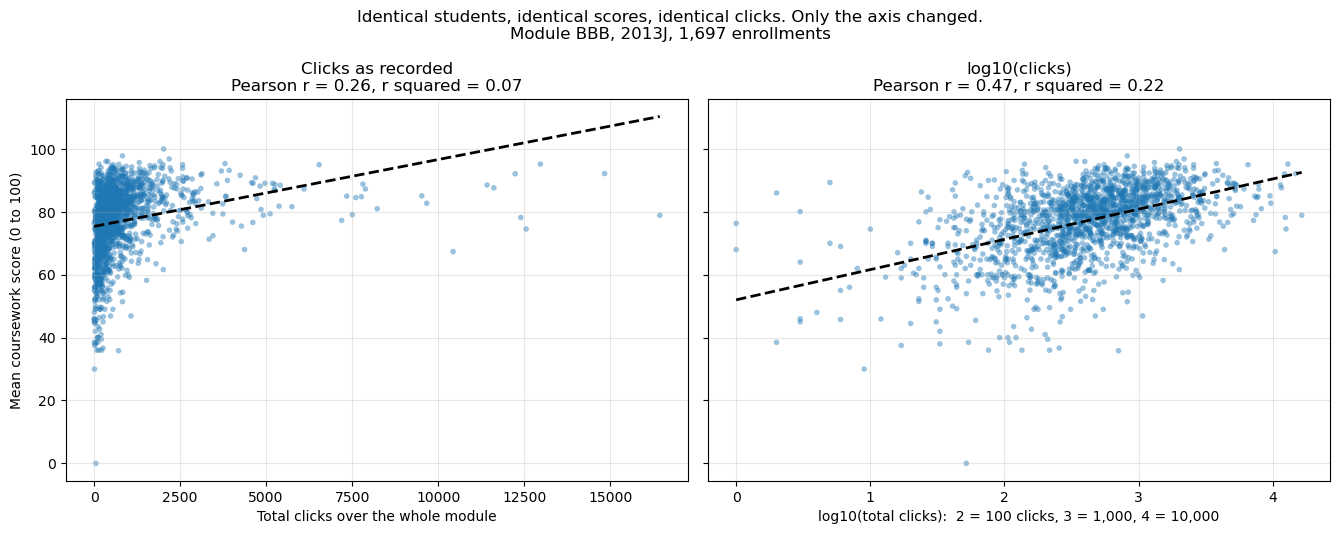

Pearson r, raw click count : 0.258   (r squared 0.067)
Pearson r, log10(clicks)   : 0.473   (r squared 0.223)
The Pearson correlation is 1.83 times larger, and the share of score
variation a straight line tracks is 3.3 times larger.

Spearman rho, raw click count : 0.466
Spearman rho, log10(clicks)   : 0.466      <- identical, to every decimal
A log leaves every enrollment in the same rank order, so a rank correlation cannot
see it at all. Nothing about the relationship got stronger. A different assumed
shape fit better.

Reported one way: "a straight line in raw clicks tracks 7% of the score variation."
Reported the other: "a straight line in log clicks tracks 22%."
Both are true about the same 1,697 enrollments, and neither says how much
clicking causes.


In [15]:
panel['log_clicks'] = np.log10(panel['total_clicks'])
r_log = panel['log_clicks'].corr(panel['mean_score'])
rho_log = panel['log_clicks'].corr(panel['mean_score'], method='spearman')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)

for ax, xcol, title, xlabel in [
        (ax1, 'total_clicks',
         f'Clicks as recorded\nPearson r = {r_raw:.2f}, r squared = {r_raw ** 2:.2f}',
         'Total clicks over the whole module'),
        (ax2, 'log_clicks',
         f'log10(clicks)\nPearson r = {r_log:.2f}, r squared = {r_log ** 2:.2f}',
         'log10(total clicks):  2 = 100 clicks, 3 = 1,000, 4 = 10,000')]:
    ax.scatter(panel[xcol], panel['mean_score'], s=16, color='#1f77b4',
               alpha=0.45, edgecolor='none')
    s, i = np.polyfit(panel[xcol], panel['mean_score'], 1)
    xs = np.linspace(panel[xcol].min(), panel[xcol].max(), 100)
    ax.plot(xs, s * xs + i, color='#000000', linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel(xlabel)

ax1.set_ylabel('Mean coursework score (0 to 100)')
fig.suptitle('Identical students, identical scores, identical clicks. Only the axis changed.\n'
             f'Module BBB, {PRESENTATION}, {len(panel):,} enrollments', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Pearson r, raw click count : {r_raw:.3f}   (r squared {r_raw ** 2:.3f})')
print(f'Pearson r, log10(clicks)   : {r_log:.3f}   (r squared {r_log ** 2:.3f})')
print(f'The Pearson correlation is {r_log / r_raw:.2f} times larger, and the share of score')
print(f'variation a straight line tracks is {(r_log ** 2) / (r_raw ** 2):.1f} times larger.')
print()
print(f'Spearman rho, raw click count : {rho:.3f}')
print(f'Spearman rho, log10(clicks)   : {rho_log:.3f}      <- identical, to every decimal')
print('A log leaves every enrollment in the same rank order, so a rank correlation cannot')
print('see it at all. Nothing about the relationship got stronger. A different assumed')
print('shape fit better.')
print()
print(f'Reported one way: "a straight line in raw clicks tracks {100 * r_raw ** 2:.0f}% of the score variation."')
print(f'Reported the other: "a straight line in log clicks tracks {100 * r_log ** 2:.0f}%."')
print(f'Both are true about the same {len(panel):,} enrollments, and neither says how much')
print('clicking causes.')

### 💬 Interpret this chart. This is the argument.

The log version is not a trick and it is not a lie. It is defensible, and here is the defense: click counts are heavy tailed, and the decile table shows the payoff flattening, so a model that treats a step of a few hundred clicks at the bottom of the distribution as equivalent to the same step at the top is modelling something nobody believes. Logging says *proportional* change is what matters. That is a claim about how learning works, and it can be argued for.

The raw version is also defensible: clicks are what the system counted, and transforming them puts a layer of your own reasoning between the reader and the record.

What is **not** defensible is choosing between them after seeing which one gives the bigger number.

Be precise about what the log bought, though, because it is easy to oversell. Spearman is 0.47 before the transformation and 0.47 after it. The association between these two columns did not change, could not have changed, and was never 0.26 in the first place. What the transformation did was replace a badly fitting straight line with a better fitting one. That is a real improvement in a model and it is not a discovery about students. A paper that reports the jump from 7 percent to 22 percent without mentioning that the rank correlation sat perfectly still is not lying, and it is letting you believe something false.

1. You are writing the results paragraph. Which numbers do you report, and what exactly do you have to say alongside them so that a reader could disagree with you?
2. A colleague reports the log version with no mention of the transformation. Is that fraud, carelessness, or normal practice? Does your answer change if they are selling a product?
3. Where does the transformation sit on the claim ladder? It is not a feature and it is not a construct. Give it a name.
4. Reich (2022) writes about studying learning at scale through whatever traces a platform happens to keep. Add a clause: and through whatever transformations the analyst happens to apply. What follows for how you read other people's findings?

## 📊 8. Look at the students the line gets wrong

A regression line is an average, and averages are the story of nobody in particular. Two views make the misses visible.

First, a summary table: split the panel into three equal groups by click volume and look at the **spread** of scores inside each group, not just the average.

In [16]:
panel['tercile'] = pd.qcut(panel['total_clicks'], 3,
                           labels=['low third', 'middle third', 'high third'])

tercile_table = (
    panel.groupby('tercile', observed=True)
         .agg(students=('id_student', 'count'),
              median_clicks=('total_clicks', 'median'),
              mean_score=('mean_score', 'mean'),
              sd_of_score=('mean_score', 'std'),
              lowest_score=('mean_score', 'min'),
              highest_score=('mean_score', 'max'))
         .round(1)
)
display(tercile_table)

high_median = panel.loc[panel['tercile'] == 'high third', 'mean_score'].median()
low_group = panel[panel['tercile'] == 'low third']
n_beat = int((low_group['mean_score'] > high_median).sum())
print(f'Median score of the HIGH click third: {high_median:.1f}')
print(f'Low click students who beat that median: {n_beat} of {len(low_group)} '
      f'({100 * n_beat / len(low_group):.1f}%)')
print(f'Distance between the low and high group means: '
      f'{tercile_table.loc["high third", "mean_score"] - tercile_table.loc["low third", "mean_score"]:.1f} points')
print(f'Spread inside the low group alone (sd): '
      f'{tercile_table.loc["low third", "sd_of_score"]:.1f} points')

,students,median_clicks,mean_score,sd_of_score,lowest_score,highest_score
tercile,,,,,,
low third,566,137.5,70.5,12.4,0.0,95.2
middle third,565,439.0,78.7,8.4,46.9,96.1
high third,566,1176.0,82.1,8.2,35.8,100.0


Median score of the HIGH click third: 83.4
Low click students who beat that median: 72 of 566 (12.7%)
Distance between the low and high group means: 11.6 points
Spread inside the low group alone (sd): 12.4 points


Read the table before the next chart. The group means climb from the low third to the high third, so the trend is real. But look at `sd_of_score`, and at `lowest_score` against `highest_score` **within** any one row: the range inside a single activity group is far wider than the distance between the groups. That is what a modest `r` looks like when you stop letting one line speak for seventeen hundred people.

Now the second view. Find the students in the **low activity, high score** corner and put them on the map: bottom third of clicks, top quarter of scores.

Click cutoff (33rd percentile) : 274 clicks
Score cutoff (75th percentile) : 84.8 points
Enrollments in the low click, high score corner: 60 of 1,697
Their median click count: 145, against 439 for the panel as a whole.

How those corner enrollments actually ended:
final_result
Distinction     9
Pass           21
Fail           17
Withdrawn      13

The ten highest scorers in that corner:


,id_student,total_clicks,active_days,n_submissions,mean_score,final_result
0,556427,141,20,6,95.166667,Withdrawn
1,398891,203,29,11,94.090909,Pass
2,2620279,136,13,5,93.200000,Withdrawn
3,517553,103,6,5,92.800000,Withdrawn
4,305935,53,5,11,92.545455,Fail
5,520006,213,20,11,92.272727,Distinction
6,574065,145,15,11,92.000000,Distinction
7,440765,137,23,3,92.000000,Fail
8,509258,259,7,4,91.500000,Fail
9,440593,51,6,8,91.500000,Pass


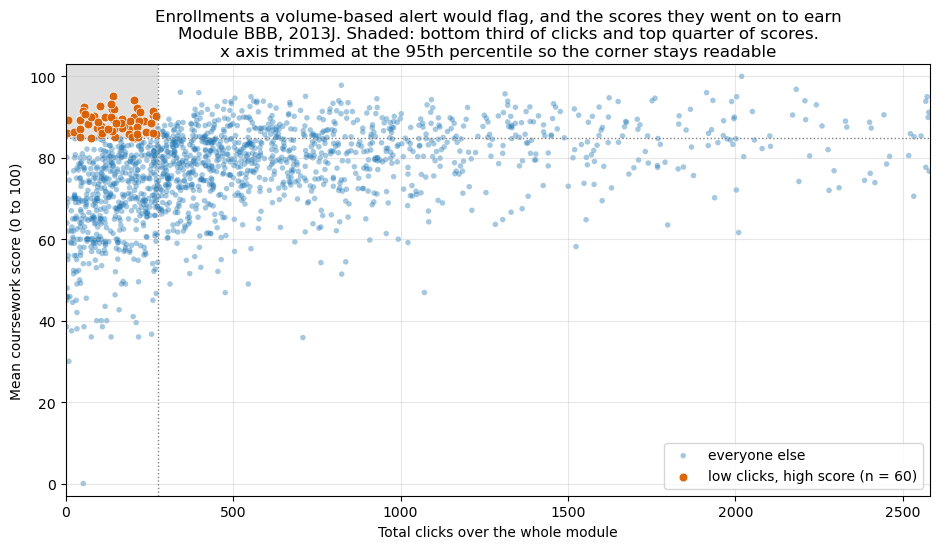

In [17]:
click_cut = panel['total_clicks'].quantile(1 / 3)
score_cut = panel['mean_score'].quantile(0.75)

corner = panel[(panel['total_clicks'] <= click_cut) & (panel['mean_score'] >= score_cut)]

print(f'Click cutoff (33rd percentile) : {click_cut:,.0f} clicks')
print(f'Score cutoff (75th percentile) : {score_cut:.1f} points')
print(f'Enrollments in the low click, high score corner: {len(corner)} of {len(panel):,}')
print(f'Their median click count: {corner["total_clicks"].median():,.0f}, '
      f'against {panel["total_clicks"].median():,.0f} for the panel as a whole.')
print()
print('How those corner enrollments actually ended:')
print(corner['final_result'].value_counts()
      .reindex(['Distinction', 'Pass', 'Fail', 'Withdrawn']).to_string())
print()
print('The ten highest scorers in that corner:')
display(corner[['id_student', 'total_clicks', 'active_days', 'n_submissions',
                'mean_score', 'final_result']]
        .sort_values('mean_score', ascending=False).head(10).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9.5, 5.6))
x_lo, x_hi = 0, panel['total_clicks'].quantile(0.95)
y_lo, y_hi = panel['mean_score'].min() - 3, 103
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)

ax.add_patch(plt.Rectangle((x_lo, score_cut), click_cut - x_lo, y_hi - score_cut,
                           facecolor='#bbbbbb', alpha=0.45, zorder=0))
ax.axhline(score_cut, color='#7f7f7f', linewidth=1, linestyle=':')
ax.axvline(click_cut, color='#7f7f7f', linewidth=1, linestyle=':')

others = panel.drop(corner.index)
ax.scatter(others['total_clicks'], others['mean_score'], s=16, color='#1f77b4',
           alpha=0.40, edgecolor='none', label='everyone else')
ax.scatter(corner['total_clicks'], corner['mean_score'], s=40, color='#d95f02',
           alpha=0.95, edgecolor='white', linewidth=0.5,
           label=f'low clicks, high score (n = {len(corner)})')

ax.set_title('Enrollments a volume-based alert would flag, and the scores they went on to earn\n'
             f'Module BBB, {PRESENTATION}. Shaded: bottom third of clicks and top quarter of scores.\n'
             'x axis trimmed at the 95th percentile so the corner stays readable')
ax.set_xlabel('Total clicks over the whole module')
ax.set_ylabel('Mean coursework score (0 to 100)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 💬 Interpret this chart

Sixty enrollments sit in the shaded corner, several of them near the top of the cohort, on roughly a third of the clicks of the median student.

1. Write **three** different stories that would produce a point in that corner. At least one should be flattering to the student, at least one should be worrying, and at least one should be about the **system** rather than the student. (This is a distance-learning module. Where else could the studying have happened?)
2. Look at the `final_result` breakdown printed above the chart, then at the table. Thirteen of these students withdrew, and one of them was carrying a coursework average above 95. What does an alert built on click volume know about that person, and what does it not know?
3. A retention model that treats low recorded activity as a warning sign would flag every one of those sixty. What is the cost of that error, and who pays it? Week 3 builds exactly that model and audits it, starting with the question of what it should be called.
4. Reverse the frame. The busiest third average only a few points above the middle third. If more recorded activity is buying so little score, what does that say about the course materials, the assessment, and the platform, before it says anything about the students? What data would tell you the difference?
5. Baker and Inventado (2014) separate discovering structure in data from acting on it. Which of the two are you doing when you circle these sixty students? Which one would you need permission for?

## ✏️ Your turn 1: three cleaning decisions, and what they cost

Every number above rests on decisions we made in Section 2. Now you make them.

Three switches. Each one is a defensible position that a real analyst has taken in a real paper. Change them, re-run, and watch two things: **how many people are left**, and **what the headline number becomes**.

The cell runs as written and reproduces the panel you already have, so run it once before you touch anything.

- `INCLUDE_PRE_START_CLICKS`: keep the clicks recorded before day 0, or throw them away because the exposure window is unequal?
- `MIN_SUBMISSIONS`: how many scored submissions must a student have before they count as having a coursework score? One is generous. Three insists on a track record.
- `KEEP_WITHDRAWN`: keep enrollments that ended in withdrawal, or restrict to students who stayed?

Nobody's behavior changes. Only who counts changes.

In [18]:
# ✏️ EDIT THESE THREE VALUES. The cell runs as written.
INCLUDE_PRE_START_CLICKS = True    # True or False
MIN_SUBMISSIONS          = 1       # 1, 2, 3, ...
KEEP_WITHDRAWN           = True    # True or False

# --- nothing below needs editing ---
def build_panel(presentation='2013J', include_pre_start=True,
                min_submissions=1, keep_withdrawn=True):
    """Rebuild the whole panel under one set of cleaning decisions."""
    roster_p = student_info[student_info['code_presentation'] == presentation]
    if not keep_withdrawn:
        roster_p = roster_p[roster_p['final_result'] != 'Withdrawn']

    log = student_vle[student_vle['code_presentation'] == presentation]
    if not include_pre_start:
        log = log[log['date'] >= 0]
    act = log.groupby('id_student').agg(total_clicks=('sum_click', 'sum')).reset_index()

    sc = submissions[submissions['code_presentation'] == presentation].dropna(subset=['score'])
    ach = (sc.groupby('id_student')
             .agg(mean_score=('score', 'mean'), n_submissions=('score', 'size'))
             .reset_index())
    ach = ach[ach['n_submissions'] >= min_submissions]

    return (roster_p[['id_student', 'final_result']]
            .merge(act, on='id_student', how='inner')
            .merge(ach, on='id_student', how='inner'))

p = build_panel(PRESENTATION, INCLUDE_PRE_START_CLICKS, MIN_SUBMISSIONS, KEEP_WITHDRAWN)
rr = p['total_clicks'].corr(p['mean_score'])
rl = np.log10(p['total_clicks']).corr(p['mean_score'])
rs = p['total_clicks'].corr(p['mean_score'], method='spearman')

print(f'pre-start clicks kept : {INCLUDE_PRE_START_CLICKS}')
print(f'minimum submissions   : {MIN_SUBMISSIONS}')
print(f'withdrawn kept        : {KEEP_WITHDRAWN}')
print('-' * 60)
print(f'enrollments analyzed  : {len(p):,}   '
      f'(baseline {len(panel):,}; started from {len(enroll):,} enrolled)')
print(f'median clicks         : {p["total_clicks"].median():,.0f}')
print(f'mean coursework score : {p["mean_score"].mean():.1f}')
print(f'share withdrawn       : {100 * (p["final_result"] == "Withdrawn").mean():.1f}%')
print(f'Pearson r, raw clicks : {rr:.3f}   (baseline {r_raw:.3f})')
print(f'Pearson r, log clicks : {rl:.3f}   (baseline {r_log:.3f})')
print(f'Spearman rho          : {rs:.3f}   (baseline {rho:.3f})')
print('-' * 60)
print(f'Enrolled people your settings leave out: {len(enroll) - len(p):,}')

pre-start clicks kept : True
minimum submissions   : 1
withdrawn kept        : True
------------------------------------------------------------
enrollments analyzed  : 1,697   (baseline 1,697; started from 2,237 enrolled)
median clicks         : 439
mean coursework score : 77.1
share withdrawn       : 12.0%
Pearson r, raw clicks : 0.258   (baseline 0.258)
Pearson r, log clicks : 0.473   (baseline 0.473)
Spearman rho          : 0.466   (baseline 0.466)
------------------------------------------------------------
Enrolled people your settings leave out: 540


**Notice what just happened.** You did not change a single student's behavior. You changed who counts, and both the sample and the headline number moved.

Write one sentence naming the setting you would defend in a methods section, and one sentence naming what a reader would need to be told about the people it removed.

One thing worth noticing specifically: the pre-start switch barely moves anything, while `MIN_SUBMISSIONS` moves a lot. Decisions are not equally consequential, and you cannot tell which is which without checking. That check has a name in the literature, a **sensitivity analysis**, and it is what separates a finding from a coincidence.

## 📊 9. When does the work happen?

So far we have squashed time flat. Every count in this notebook has treated a click on day 3 and a click on day 200 as the same thing. Time is usually where the educational story actually lives.

This module ran for months and had assignments due on known days. Let us count clicks per day and mark every due date. Then, beside it, count how many distinct students were still active in each week of the module.

Tutor-marked assignment due days   : [19, 47, 96, 131, 166, 208]
Computer-marked assignment due days: [54, 96, 131, 166, 208]
The exam has no due day recorded and no submissions in the file.

Days of activity before the module opens: 11, carrying 63,524 clicks (4.6% of the total).
Busiest day: day 2, 19,872 clicks from 698 students.
Mean clicks per day from day 0 onward: 4,889
Mean clicks per day in the 7 days up to the first assignment (day 19): 10,662

Distinct students active in module week 0  : 1,372
Distinct students active in module week 38 : 191

Weeks the line went UP rather than down: 14 of 38
The five biggest rebounds, by week: [12, 13, 29, 23, 34]
Weeks a tutor-marked assignment was due: [2, 6, 13, 18, 23, 29]
Attrition here is a sawtooth, not a slide.


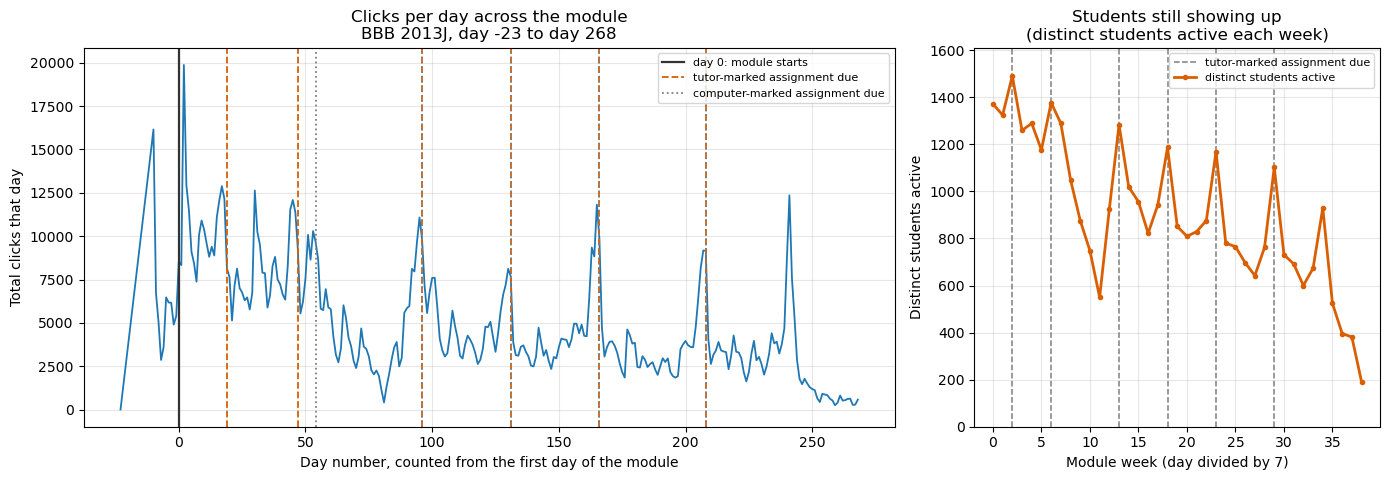

In [19]:
daily = (vle_log.groupby('date')
                .agg(clicks=('sum_click', 'sum'), students=('id_student', 'nunique'))
                .reset_index())

due = assessments[(assessments['code_presentation'] == PRESENTATION)
                  & assessments['date'].notna()]
tma_days = sorted(due[due['assessment_type'] == 'TMA']['date'].tolist())
cma_days = sorted(due[due['assessment_type'] == 'CMA']['date'].tolist())
print('Tutor-marked assignment due days   :', [int(v) for v in tma_days])
print('Computer-marked assignment due days:', [int(v) for v in cma_days])
print('The exam has no due day recorded and no submissions in the file.')
print()

pre_days = daily[daily['date'] < 0]
print(f'Days of activity before the module opens: {len(pre_days)}, '
      f'carrying {pre_days["clicks"].sum():,} clicks '
      f'({100 * pre_days["clicks"].sum() / daily["clicks"].sum():.1f}% of the total).')
peak = daily.loc[daily['clicks'].idxmax()]
print(f'Busiest day: day {int(peak["date"])}, {int(peak["clicks"]):,} clicks '
      f'from {int(peak["students"]):,} students.')
print(f'Mean clicks per day from day 0 onward: '
      f'{daily.loc[daily["date"] >= 0, "clicks"].mean():,.0f}')
first_due = tma_days[0]
print(f'Mean clicks per day in the 7 days up to the first assignment (day {int(first_due)}): '
      f'{daily[(daily["date"] >= first_due - 6) & (daily["date"] <= first_due)]["clicks"].mean():,.0f}')
print()

weekly = (vle_log[vle_log['date'] >= 0]
          .assign(week=lambda t: t['date'] // 7)
          .groupby('week')['id_student'].nunique())
print(f'Distinct students active in module week {weekly.index[0]}  : {weekly.iloc[0]:,}')
print(f'Distinct students active in module week {weekly.index[-1]} : {weekly.iloc[-1]:,}')
print()

# The weekly line trends down, but it does not fall smoothly. Where does it bounce?
tma_weeks = sorted({int(v) // 7 for v in tma_days})
change = weekly.diff()
rises = change[change > 0].sort_values(ascending=False)
print(f'Weeks the line went UP rather than down: {int((change > 0).sum())} of '
      f'{int(change.notna().sum())}')
print(f'The five biggest rebounds, by week: {[int(w) for w in rises.head(5).index]}')
print(f'Weeks a tutor-marked assignment was due: {tma_weeks}')
print('Attrition here is a sawtooth, not a slide.')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.9),
                               gridspec_kw={'width_ratios': [2.0, 1.0]})

ax1.plot(daily['date'], daily['clicks'], color='#1f77b4', linewidth=1.3)
ax1.axvline(0, color='#333333', linewidth=1.6, label='day 0: module starts')
for i, dday in enumerate(tma_days):
    ax1.axvline(dday, color='#d95f02', linestyle='--', linewidth=1.3,
                label='tutor-marked assignment due' if i == 0 else None)
for i, dday in enumerate(cma_days):
    ax1.axvline(dday, color='#7f7f7f', linestyle=':', linewidth=1.3,
                label='computer-marked assignment due' if i == 0 else None)
ax1.set_title(f'Clicks per day across the module\nBBB {PRESENTATION}, '
              f'day {int(daily["date"].min())} to day {int(daily["date"].max())}')
ax1.set_xlabel('Day number, counted from the first day of the module')
ax1.set_ylabel('Total clicks that day')
ax1.legend(fontsize=8, loc='upper right')

for i, w in enumerate(tma_weeks):
    ax2.axvline(w, color='#7f7f7f', linestyle='--', linewidth=1.1,
                label='tutor-marked assignment due' if i == 0 else None)
ax2.plot(weekly.index, weekly.values, color='#d95f02', linewidth=2, marker='o', markersize=3,
         label='distinct students active')
ax2.set_title('Students still showing up\n(distinct students active each week)')
ax2.set_xlabel('Module week (day divided by 7)')
ax2.set_ylabel('Distinct students active')
ax2.set_ylim(0, weekly.max() * 1.08)
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

### 💬 Interpret this chart

1. The left panel has a shape you could set a clock by. Describe the cycle in one sentence, then name the thing in the course design that produces it.
2. Most orange lines are followed by a drop. Is that a finding about students, or a finding about the course? What would this panel look like in a module with no fixed due dates?
3. The right panel is attrition drawn as a line, and it is not a smooth slide. It starts at 1,372 students, ends at 191, and goes back up in 14 of its 38 steps. Compare the printed list of the five biggest rebounds against the printed list of assignment weeks: three of the five land exactly on a tutor-marked deadline week, and a fourth is the week right before one. Say what that sawtooth means. Are those students returning to the course, or returning to the assignment, and would a dashboard that counts weekly active users be able to tell the difference? Then: at which week would you have wanted an intervention, and what does the panel tell you about whether the people you wanted to reach were still there to receive it?
4. Clicks keep going after the last assignment due day. What are those people doing, and which column in this dataset would you check first?
5. Reich (2022) writes about what happens when learning is studied at scale through the traces platforms happen to keep. What is this rhythm mostly a trace of: the students, or the calendar the institution imposed on them?

## ✏️ Your turn 2: the other year

Section 2e cut the data in half and analyzed 2013J. The other half is sitting right there.

Set `WHICH_PRESENTATION` to `'2014J'` and re-run. Same module, same university, same code, one year later. Then decide what you now believe.

Presentation          : 2013J
Enrolled              : 2,237
In the panel          : 1,697
Median clicks         : 439
Mean coursework score : 77.1
Pearson r, raw clicks : 0.258
Pearson r, log clicks : 0.473
Spearman rho          : 0.466

Assessments in this presentation:
assessment_type  date  weight
            CMA  54.0     1.0
            CMA  96.0     1.0
            CMA 131.0     1.0
            CMA 166.0     1.0
            CMA 208.0     1.0
            TMA  19.0     5.0
            TMA  47.0    18.0
            TMA  96.0    18.0
            TMA 131.0    18.0
            TMA 166.0    18.0
            TMA 208.0    18.0
           Exam   NaN   100.0



And if you pooled the two years into one analysis: n = 3,485, Pearson r on log clicks = 0.218, Spearman rho = 0.150


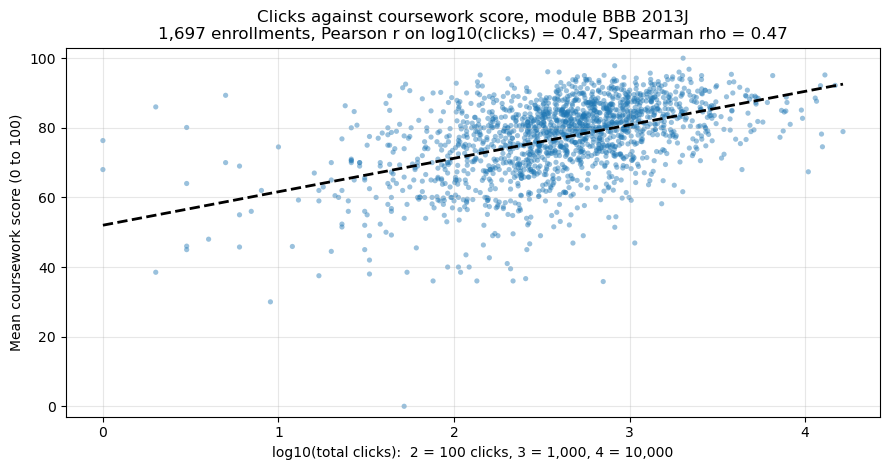

In [20]:
# ✏️ EDIT THIS. Either '2013J' or '2014J'. It runs as written.
WHICH_PRESENTATION = '2013J'

# --- nothing below needs editing ---
if WHICH_PRESENTATION not in ('2013J', '2014J'):
    print(f'"{WHICH_PRESENTATION}" is not a presentation in this file. Using 2013J instead.')
    WHICH_PRESENTATION = '2013J'

q = build_panel(WHICH_PRESENTATION)
q_r_raw = q['total_clicks'].corr(q['mean_score'])
q_r_log = np.log10(q['total_clicks']).corr(q['mean_score'])
q_rho   = q['total_clicks'].corr(q['mean_score'], method='spearman')
n_enrolled = int((student_info['code_presentation'] == WHICH_PRESENTATION).sum())

print(f'Presentation          : {WHICH_PRESENTATION}')
print(f'Enrolled              : {n_enrolled:,}')
print(f'In the panel          : {len(q):,}')
print(f'Median clicks         : {q["total_clicks"].median():,.0f}')
print(f'Mean coursework score : {q["mean_score"].mean():.1f}')
print(f'Pearson r, raw clicks : {q_r_raw:.3f}')
print(f'Pearson r, log clicks : {q_r_log:.3f}')
print(f'Spearman rho          : {q_rho:.3f}')
print()
print('Assessments in this presentation:')
print(assessments[assessments['code_presentation'] == WHICH_PRESENTATION]
      [['assessment_type', 'date', 'weight']].to_string(index=False))
print()

pooled = pd.concat([build_panel('2013J'), build_panel('2014J')], ignore_index=True)
print(f'And if you pooled the two years into one analysis: n = {len(pooled):,}, '
      f'Pearson r on log clicks = '
      f'{np.log10(pooled["total_clicks"]).corr(pooled["mean_score"]):.3f}, '
      f'Spearman rho = '
      f'{pooled["total_clicks"].corr(pooled["mean_score"], method="spearman"):.3f}')

fig, ax = plt.subplots(figsize=(9, 4.8))
xv = np.log10(q['total_clicks'])
ax.scatter(xv, q['mean_score'], s=14, color='#1f77b4', alpha=0.45, edgecolor='none')
s, i = np.polyfit(xv, q['mean_score'], 1)
xs = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xs, s * xs + i, color='#000000', linewidth=2, linestyle='--')
ax.set_title(f'Clicks against coursework score, module BBB {WHICH_PRESENTATION}\n'
             f'{len(q):,} enrollments, Pearson r on log10(clicks) = {q_r_log:.2f}, '
             f'Spearman rho = {q_rho:.2f}')
ax.set_xlabel('log10(total clicks):  2 = 100 clicks, 3 = 1,000, 4 = 10,000')
ax.set_ylabel('Mean coursework score (0 to 100)')
ax.set_ylim(-3, 103)
plt.tight_layout()
plt.show()

### 💬 Interpret this chart

1. Run it both ways and write down, for each year, the Pearson `r` on log clicks and the Spearman rho. Would you describe them as the same finding? Notice that the two years disagree more sharply on Spearman than the Pearson numbers alone suggested.
2. The mean coursework score is very different between the two years. Look at the assessment table printed above before you explain why. What changed about the course, and does that make the two years comparable at all?
3. You have one module, two years, and two answers. If you had pooled them into a single analysis, which of those two answers would you have gotten, and would you have known you had a problem?
4. Somebody asks you what the relationship between activity and achievement is in module BBB. What is the honest reply?

## ✏️ Your turn 3: which clicks count as engagement?

`total_clicks` counts every click on every kind of resource: the forum, the homepage, quizzes, PDFs, links out. That is a decision, and decisions can be changed.

`vle.csv` labels every resource with an `activity_type`. Pick the types you think belong in an "engagement" indicator and re-run. Watch two numbers: the correlation, and **how many students vanish** because they never touched the thing you chose.

In [21]:
# ✏️ EDIT THIS LIST. It runs as written; the default keeps every activity type.
ACTIVITY_TYPES = ['forumng', 'homepage', 'quiz', 'subpage', 'resource',
                  'url', 'oucontent', 'glossary', 'oucollaborate', 'sharedsubpage']

# --- nothing below needs editing ---
sites = vle[vle['code_presentation'] == PRESENTATION][['id_site', 'activity_type']]
labelled = vle_log.merge(sites, on='id_site', how='left')

print('Clicks by activity type in this presentation:')
print(labelled.groupby('activity_type')['sum_click'].sum()
              .sort_values(ascending=False).map('{:,}'.format).to_string())
print()

chosen = [t for t in ACTIVITY_TYPES if t in set(labelled['activity_type'].dropna())]
if not chosen:
    print('None of those names matched an activity type. Using all of them instead.')
    chosen = sorted(labelled['activity_type'].dropna().unique().tolist())

kept = labelled[labelled['activity_type'].isin(chosen)]
feature = (kept.groupby('id_student')['sum_click'].sum()
               .rename('chosen_clicks').reset_index())

check = panel[['id_student', 'mean_score']].merge(feature, on='id_student', how='inner')
c_raw = check['chosen_clicks'].corr(check['mean_score'])
c_log = np.log10(check['chosen_clicks']).corr(check['mean_score'])
c_rho = check['chosen_clicks'].corr(check['mean_score'], method='spearman')

print(f'Counting: {", ".join(chosen)}')
print(f'Clicks kept   : {kept["sum_click"].sum():,} of {labelled["sum_click"].sum():,}')
print(f'Students left : {len(check):,} of {len(panel):,}   '
      f'({len(panel) - len(check)} vanished, having never touched these resources)')
print(f'Pearson r, raw counts : {c_raw:.3f}   (all types: {r_raw:.3f})')
print(f'Pearson r, log counts : {c_log:.3f}   (all types: {r_log:.3f})')
print(f'Spearman rho          : {c_rho:.3f}   (all types: {rho:.3f})')

Clicks by activity type in this presentation:
activity_type
forumng          702,326
homepage         344,964
quiz             118,688
subpage           81,487
resource          54,615
url               38,575
oucontent         34,877
glossary           1,916
oucollaborate      1,144
sharedsubpage         64



Counting: forumng, homepage, quiz, subpage, resource, url, oucontent, glossary, oucollaborate, sharedsubpage
Clicks kept   : 1,378,656 of 1,378,656
Students left : 1,697 of 1,697   (0 vanished, having never touched these resources)
Pearson r, raw counts : 0.258   (all types: 0.258)
Pearson r, log counts : 0.473   (all types: 0.473)
Spearman rho          : 0.466   (all types: 0.466)


**Notice what just happened.** You changed a definition, not a fact about any student, and the number a dashboard would report about them moved.

Now the harder half. Every student who "vanished" did not stop existing; they stopped being measurable by your definition. Write one sentence naming which candidate feature you would be willing to defend **in front of the student it describes**, and one sentence about what you owe the students your definition erased.

## 💬 10. Reflection: two traditions, one scatterplot, one real cohort

Take ten minutes with a partner. These questions are the reason the notebook exists.

**1. Baker and Inventado (2014), educational data mining and learning analytics.**
Today you did something both traditions do: reduce behavior to features, then look for structure. Sketch the next step twice.
- The educational data mining version: what would you automate, model, or predict from this panel?
- The learning analytics version: whose decision would you inform, what would you show them, and how would a human's judgment stay in the loop?
Which of the two is your course project closer to right now, and is that on purpose?

**2. Nathan and Sawyer (2014), foundations of the learning sciences.**
Nathan and Sawyer describe learning as deep conceptual understanding built through activity in context, not as accumulated exposure. Look back at Section 6.
- Which rung of the claim ladder can `total_clicks` actually reach, on their account of learning?
- This was a distance-learning module. Name one thing a learning sciences researcher would want to observe about it that leaves no trace in any file we opened today.
- If you could add exactly one new column to this dataset to get closer to their idea of learning, what would it be, and how would you collect it without surveilling anybody?

**3. Reich (2022), learning analytics and learning at scale.**
Section 7 gave you two true sentences about the same people, one reporting a small share of score variation tracked by a straight line in raw clicks and one reporting roughly three times as much, differing only in the axis, while the rank correlation underneath both of them did not move at all.
- What does that do to your reading of any single reported effect size in the literature?
- If a paper reports one correlation and does not say what shape it assumed, what would you have to ask for before you believed it?
- Reich argues that scale changes what can be known. Does it also change what can be *claimed*? Who checks?

**4. The people who are not in the panel.**
Every enrollment our inner join set aside had failed or withdrawn. Not one had passed.
- Write the sentence you would put in a limitations section. Then write the sentence you would put in an abstract, and notice whether they are the same sentence.
- Whose responsibility is it that the students most likely to need help are the students least visible in the data? Is that a technical problem, a design problem, or a political one?

**5. One question this data cannot answer.**
Write it down. Bring it to the discussion. The best course projects in this seminar have started as exactly this kind of sentence.

## ✅ 11. Wrap up

**Nothing is due on Canvas for Week 2.** This notebook is in-class work. Mini Project 1 arrives in Week 4, and that is when the formal submission routine starts.

Before you close the tab:

- [ ] The notebook ran top to bottom with no red error boxes.
- [ ] You can state where this data came from, who collected it, and under what license, without scrolling up.
- [ ] You edited at least one ✏️ **Your turn** cell and saw a number move.
- [ ] You wrote something in the claim ladder text cell in Section 4.
- [ ] You can say, in one sentence, what our analysis panel is a sample **of**.
- [ ] You have one sentence ready for discussion: a question this data cannot answer.
- [ ] Save your copy: **File > Save a copy in Drive**. Colab sessions do not persist, and the download runs again from scratch next time.

**On AI use.** No AI documentation is required this week, because nothing is submitted. Starting with Mini Project 1 in Week 4, every mini project upload to Canvas includes your completed notebook **plus** an AI interaction log **plus** a short reflection on how you used AI, per the course AI policy. Undisclosed AI use is an Honor Code matter. If you used a chatbot to make sense of `groupby` today, that is a fine use, and it is worth starting the habit now: keep a note of what you asked and what you did with the answer.

**On citing the data.** If any part of your course project uses this dataset, the CC BY 4.0 license requires attribution. Cite Kuzilek, Hlosta, and Zdrahal (2017), *Scientific Data, 4*, 170171, and say which module and presentation you used. "OULAD" on its own is not a citation.

**Coming in Week 3.** We take the activity features you built today and train a model that predicts one thing: whether an enrollment ends in Fail or Withdrawn. Then we audit who it flags and who it misses, by subgroup. The first decision we make together is what to call the thing being predicted, because the field's usual name for it describes a person rather than an outcome, and naming is where a pipeline starts. The sixty enrollments in the corner will be waiting, and so will `imd_band`, with its inconsistent label and its blanks.

## Appendix: solutions to the ✏️ Your turn cells

Try each one yourself first. These are here so nobody gets stuck, and so you can check your reading of the output.

### Your turn 1: three cleaning decisions

The baseline, and three worth trying:

```python
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = True    # n = 1,697, Pearson 0.258 raw / 0.473 log, Spearman 0.466
INCLUDE_PRE_START_CLICKS = False ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = True    # n = 1,695, Pearson 0.256 raw / 0.462 log, Spearman 0.463
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = False   # n = 1,494, Pearson 0.260 raw / 0.471 log, Spearman 0.465
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 3 ; KEEP_WITHDRAWN = True    # n = 1,512, Pearson 0.232 raw / 0.382 log, Spearman 0.396
```

What to notice: the pre-start switch is nearly free, costing two enrollments and moving the raw Pearson by two thousandths and the log Pearson by about a hundredth. Dropping withdrawn enrollments costs 203 rows and barely moves anything, which is its own finding: by the time an enrollment has both clicks and submitted coursework, the withdrawn label is not doing much work. Requiring three submissions costs 185 rows and knocks about a fifth off both the log Pearson and the Spearman, because it removes exactly the enrollments whose short records were carrying the low end of the relationship. That last one is the only switch that moves the rank correlation, which is how you can tell it changed the sample rather than the fit.

The lesson is not that one setting is right. It is that three defensible decisions produce four different papers, and only one of them usually gets reported.

### Your turn 2: the other year

```python
WHICH_PRESENTATION = '2013J'   # n = 1,697, Pearson 0.258 raw / 0.473 log, Spearman 0.466, mean score 77.1
WHICH_PRESENTATION = '2014J'   # n = 1,788, Pearson 0.144 raw / 0.195 log, Spearman 0.106, mean score 64.3
```

What to notice: the relationship in 2014J is well under half as strong on the log scale, and the mean coursework score is about thirteen points lower. The assessment table explains a lot of it. 2013J ran six tutor-marked and five computer-marked assignments; 2014J ran five tutor-marked assignments and one of those was weighted zero. Different instruments, different difficulty, different scores.

The Spearman pair makes the gap between the years look wider, not narrower: 0.47 against 0.11. Whatever ordering held in 2013J barely held in 2014J, and a single year would have handed you a confident story.

Pool the two years into one analysis and the Pearson on log clicks comes out near 0.22 and the Spearman near 0.15, lower than 2013J, higher than 2014J, and a description of neither. That is the whole argument for keeping the presentations apart, and it is why "we analyzed module BBB" is not an adequate methods sentence.

### Your turn 3: which clicks count

```python
ACTIVITY_TYPES = ['forumng']                       # Pearson on log 0.402, Spearman 0.419,  76 enrollments vanish
ACTIVITY_TYPES = ['quiz']                          # Pearson on log 0.393, Spearman 0.317, 107 enrollments vanish
ACTIVITY_TYPES = ['oucontent']                     # Pearson on log 0.411, Spearman 0.390, 201 enrollments vanish
ACTIVITY_TYPES = ['forumng', 'oucontent', 'quiz']  # Pearson on log 0.475, Spearman 0.465,  19 enrollments vanish
```

What to notice: no single activity type carries a stronger signal than the whole pile, and the narrower your definition the more enrollments it erases. `oucontent`, the actual course material, loses 201 enrollments with no recorded click on it in a form the log recognized. A feature that quietly removes two hundred people is not a neutral measurement choice.

Notice too that `quiz` clicks look competitive with forum clicks on Pearson and clearly worse on Spearman, 0.32 against 0.42. The two statistics rank these candidate features differently, which is worth one uncomfortable minute: whichever one you report first is a choice, and you either made it before you saw the numbers or after. Then ask whether "clicking a quiz" is an indicator of engagement or an indicator of *being assessed*, and whether a dashboard built on quiz clicks is measuring the student or the calendar.